In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tqdm.keras import TqdmCallback

from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
SKENARIO = 'LAB'  # RGB / LAB / YCBCR
IMG_SIZE = 224
BATCH_SIZE = 16

LEARNING_RATE_STAGE1 = 1e-4
# LEARNING_RATE_STAGE2 = 1e-5

FOLDER_FINAL = f'/content/drive/MyDrive/skripsi/final_split_{SKENARIO}'
MODEL_SAVE_PATH = f'/content/drive/MyDrive/skripsi/model_best_{SKENARIO}.h5'

print("Skenario:", SKENARIO)

Skenario: LAB


In [ ]:
train_datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
    # rescale=1./255 DIHAPUS
)

val_test_datagen = ImageDataGenerator()

train_gen = train_datagen.flow_from_directory(
    os.path.join(FOLDER_FINAL, 'train'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_gen = val_test_datagen.flow_from_directory(
    os.path.join(FOLDER_FINAL, 'val'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    os.path.join(FOLDER_FINAL, 'test'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 2950 images belonging to 4 classes.
Found 841 images belonging to 4 classes.
Found 427 images belonging to 4 classes.


In [ ]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = True

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(train_gen.num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_STAGE1),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,384,679 (16.73 MB)

 Trainable params: 4,339,584 (16.55 MB)

 Non-trainable params: 45,095 (176.16 KB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8, # Naikkan sedikit kesabarannya menjadi 8 atau 10
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=4, # Biarkan learning rate turun pelan-pelan jika stagnan
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    MODEL_SAVE_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

callbacks = [
    early_stop,
    reduce_lr,
    checkpoint,
    TqdmCallback(verbose=1) # Tambahkan di sini
]

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

In [ ]:
EPOCHS_STAGE1 = 40
# EPOCHS_STAGE2 = 15

In [ ]:
history_stage1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_STAGE1, # Atau EPOCHS jika Anda pakai 1 stage
    callbacks=callbacks,
    verbose=0  # MATIKAN progress bar bawaan Keras
)


Epoch 1: val_accuracy improved from None to 0.77646, saving model to /content/drive/MyDrive/skripsi/model_best_LAB.h5



Epoch 1: finished saving model to /content/drive/MyDrive/skripsi/model_best_LAB.h5

Epoch 2: val_accuracy improved from 0.77646 to 0.86920, saving model to /content/drive/MyDrive/skripsi/model_best_LAB.h5



Epoch 2: finished saving model to /content/drive/MyDrive/skripsi/model_best_LAB.h5

Epoch 3: val_accuracy improved from 0.86920 to 0.89893, saving model to /content/drive/MyDrive/skripsi/model_best_LAB.h5



Epoch 3: finished saving model to /content/drive/MyDrive/skripsi/model_best_LAB.h5

Epoch 4: val_accuracy improved from 0.89893 to 0.90488, saving model to /content/drive/MyDrive/skripsi/model_best_LAB.h5



Epoch 4: finished saving model to /content/drive/MyDrive/skripsi/model_best_LAB.h5

Epoch 5: val_accuracy improved from 0.90488 to 0.90963, saving model to /content/drive/MyDrive/skripsi/model_best_LAB.h5



Epoch 5: finished saving model to /content/drive/MyDrive/skripsi/model_best_LAB.h5

Epoch 6: val_accuracy improved from 0.90963 to 0.93103, saving model to /content/drive/MyDrive/skripsi/model_best_LAB.h5



Epoch 6: finished saving model to /content/drive/MyDrive/skripsi/model_best_LAB.h5

Epoch 7: val_accuracy did not improve from 0.93103

Epoch 8: val_accuracy did not improve from 0.93103

Epoch 9: val_accuracy did not improve from 0.93103

Epoch 10: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.

Epoch 10: val_accuracy did not improve from 0.93103

Epoch 11: val_accuracy did not improve from 0.93103

Epoch 12: val_accuracy did not improve from 0.93103

Epoch 13: val_accuracy did not improve from 0.93103

Epoch 14: ReduceLROnPlateau reducing learning rate to 8.999999772640877e-06.

Epoch 14: val_accuracy did not improve from 0.93103
Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 6.


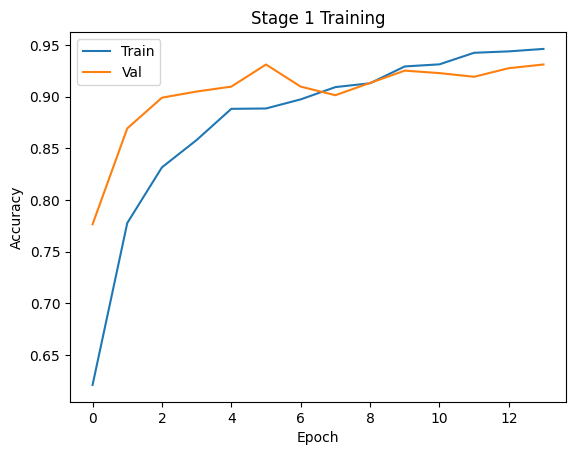

In [ ]:
def plot_history(history, title):
    plt.figure()
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(title)
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Val'])
    plt.show()

plot_history(history_stage1, "Stage 1 Training")

27/27 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step

Classification Report:

                      precision    recall  f1-score   support

            cataract       0.91      0.97      0.94       105
diabetic_retinopathy       1.00      0.98      0.99       111
            glaucoma       0.93      0.76      0.84       102
              normal       0.81      0.91      0.86       109

            accuracy                           0.91       427
           macro avg       0.91      0.91      0.91       427
        weighted avg       0.91      0.91      0.91       427



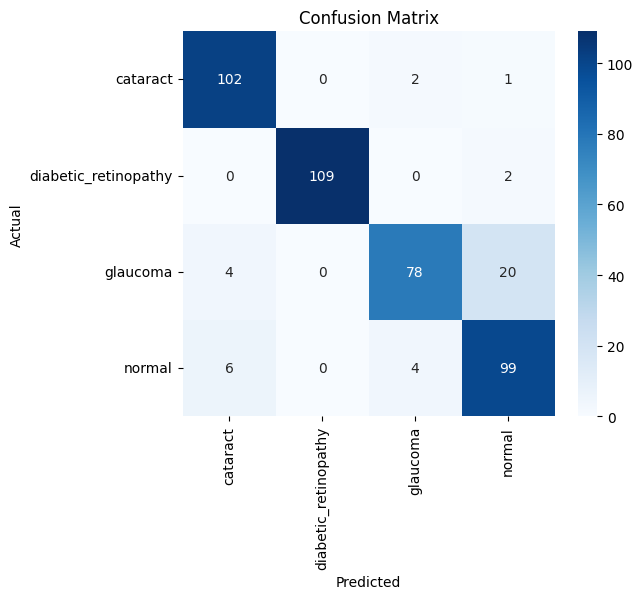

In [ ]:
model.load_weights(MODEL_SAVE_PATH)

pred_probs = model.predict(test_gen)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes

class_labels = list(test_gen.class_indices.keys())

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Tabel Detail Metrik Evaluasi per Kelas:


,precision,recall,f1-score
cataract,0.910714,0.971429,0.940092
diabetic_retinopathy,1.000000,0.981982,0.990909
glaucoma,0.928571,0.764706,0.838710
normal,0.811475,0.908257,0.857143


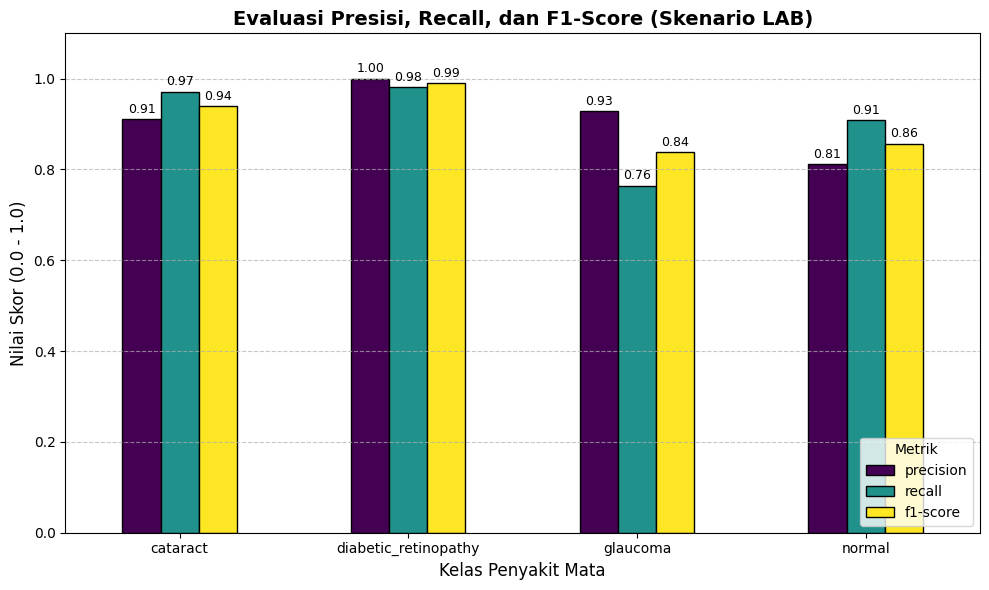

In [ ]:
import pandas as pd

# 1. Ekstrak data classification report menjadi format Dictionary (kamus data)
# Ingat untuk menggunakan variabel y_true, y_pred, dan class_labels yang sudah ada
report_dict = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)

# 2. Konversi ke Pandas DataFrame agar lebih mudah diolah
df_report = pd.DataFrame(report_dict).transpose()

# 3. Filter data: Kita hanya ingin mengambil data per kelas penyakit saja
# (Abaikan baris 'accuracy', 'macro avg', dan 'weighted avg' untuk plot ini)
df_class_metrics = df_report.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

# 4. Tampilkan dalam bentuk tabel rapi di notebook
print("Tabel Detail Metrik Evaluasi per Kelas:")
# Menampilkan kolom precision, recall, f1-score (mengabaikan kolom 'support')
display(df_class_metrics[['precision', 'recall', 'f1-score']])

# 5. Buat Visualisasi Plot (Grouped Bar Chart)
# Menggunakan pandas built-in plotting yang digabung dengan matplotlib
ax = df_class_metrics[['precision', 'recall', 'f1-score']].plot(
    kind='bar',
    figsize=(10, 6),
    colormap='viridis', # Skema warna yang elegan dan ilmiah
    edgecolor='black'
)

# Kustomisasi tampilan plot agar layak masuk skripsi
plt.title('Evaluasi Presisi, Recall, dan F1-Score (Skenario LAB)', fontsize=14, fontweight='bold')
plt.xlabel('Kelas Penyakit Mata', fontsize=12)
plt.ylabel('Nilai Skor (0.0 - 1.0)', fontsize=12)
plt.xticks(rotation=0) # Menjaga agar nama penyakit tidak miring
plt.legend(loc='lower right', title="Metrik")
plt.ylim(0, 1.1) # Set batas atas grafik sedikit lebih dari 1 agar tidak mepet
plt.grid(axis='y', linestyle='--', alpha=0.7) # Garis bantu horizontal

# (Opsional) Menambahkan angka eksak di atas setiap batang grafik
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 7),
                textcoords='offset points',
                fontsize=9)

plt.tight_layout()
plt.show()

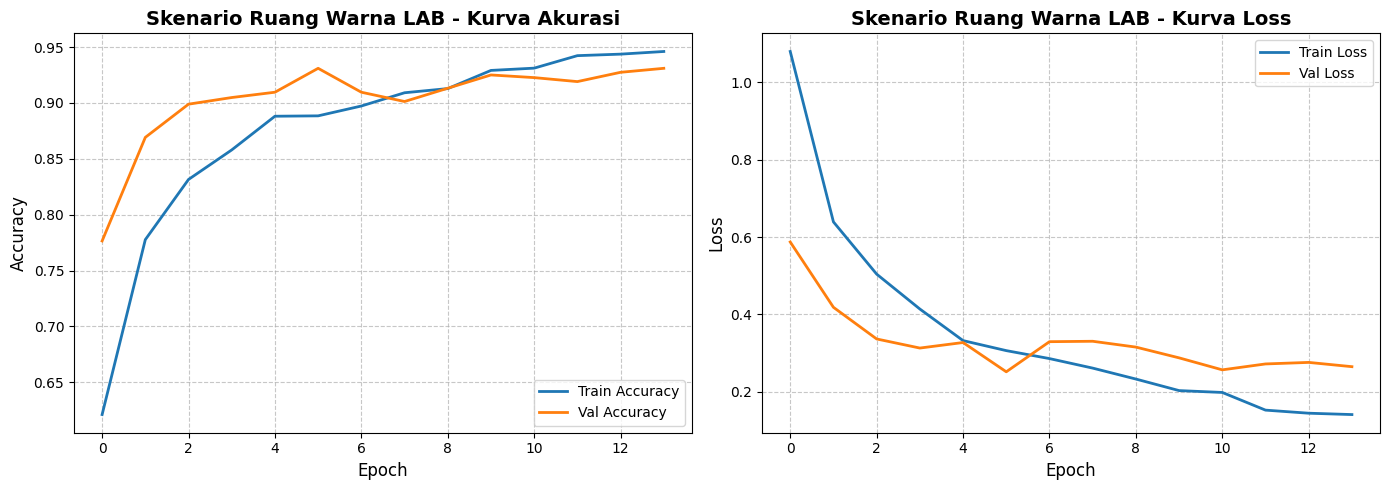

In [ ]:
import matplotlib.pyplot as plt

def plot_training_metrics(history, title_prefix="Training"):
    # Membuat figure dengan 1 baris dan 2 kolom (berdampingan)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ==========================
    # 1. Grafik Akurasi (Kiri)
    # ==========================
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    axes[0].set_title(f'{title_prefix} - Kurva Akurasi', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].legend(loc='lower right')
    axes[0].grid(True, linestyle='--', alpha=0.7) # Tambahan garis bantu

    # ==========================
    # 2. Grafik Loss (Kanan)
    # ==========================
    axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[1].set_title(f'{title_prefix} - Kurva Loss', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Loss', fontsize=12)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].legend(loc='upper right')
    axes[1].grid(True, linestyle='--', alpha=0.7)

    # Mengatur jarak antar grafik agar tidak berdempetan
    plt.tight_layout()
    plt.show()

# Cara memanggilnya tetap menggunakan variabel history yang sudah Anda jalankan
plot_training_metrics(history_stage1, "Skenario Ruang Warna LAB")

In [ ]:
import json
import os

# Mengambil data kamus (dictionary)
history_dict = history_stage1.history

file_path_history = '/content/drive/MyDrive/skripsi/history_LAB.json'

# Menyimpan data dictionary tersebut ke dalam file JSON
with open(file_path_history, 'w') as f:
    json.dump(history_dict, f)

print(f"Riwayat training berhasil disimpan ke: {file_path_history}")

Riwayat training berhasil disimpan ke: /content/drive/MyDrive/skripsi/history_LAB.json
